In [1]:
import pandas as pd 
import numpy as np 
from custom import get_metrics

gru_val = pd.read_csv('/var/www/python/Qingcheng/WFiles/Ultra/GRU_val_2026-04-27.csv')
gru_feature = pd.read_csv('/var/www/python/Qingcheng/WFiles/Ultra/GRU_features_2026-04-27.csv')
nn_val = pd.read_csv('/var/www/python/Qingcheng/WFiles/Ultra/NN_val_2026-04-28.csv')

Here the job starts!
2026-04-29 14:47:55.276298


In [5]:
feature_table = gru_feature.groupby(['feature'])["importance"].agg(count='count', mean='mean', median='median')
display(feature_table.sort_values(['count'],ascending=False)[:50].round(2))
display(feature_table.sort_values(['median'],ascending=False)[:20].round(2))

,count,mean,median
feature,,,
dayzer_slack,167,0.08,0.05
dayzer_lmp,150,0.07,0.05
INDIANAHUB_ice_elec_price_forecast_f,140,0.07,0.05
da_totalMinus1D,139,0.05,0.04
NYISO_node_2_dalmp_total_f,114,0.11,0.07
natural_gas_henry_effect,110,0.11,0.08
natural_gas_henry_f,106,0.17,0.07
SPPSimHr_da_total,73,0.04,0.03
da_totalHistory,63,0.04,0.03


,count,mean,median
feature,,,
topeka_ks_81_temperature_humidity_index,1,0.39,0.39
loadStress_LNTEKAMHOS536899_f,1,0.22,0.22
springfield_mo_129_temperature_humidity_index,1,0.18,0.18
wichita_ks_83_temperature_humidity_index,5,0.13,0.14
loadStress_XFMRKELLKE653131_f,1,0.11,0.11
spp_south_wind_chill_index,6,0.14,0.11
windStress_LNPTRBRG_N784821_f,1,0.11,0.11
spp_south_temperature_degf,7,0.10,0.11
salina_ks_199_windspeed,2,0.11,0.11


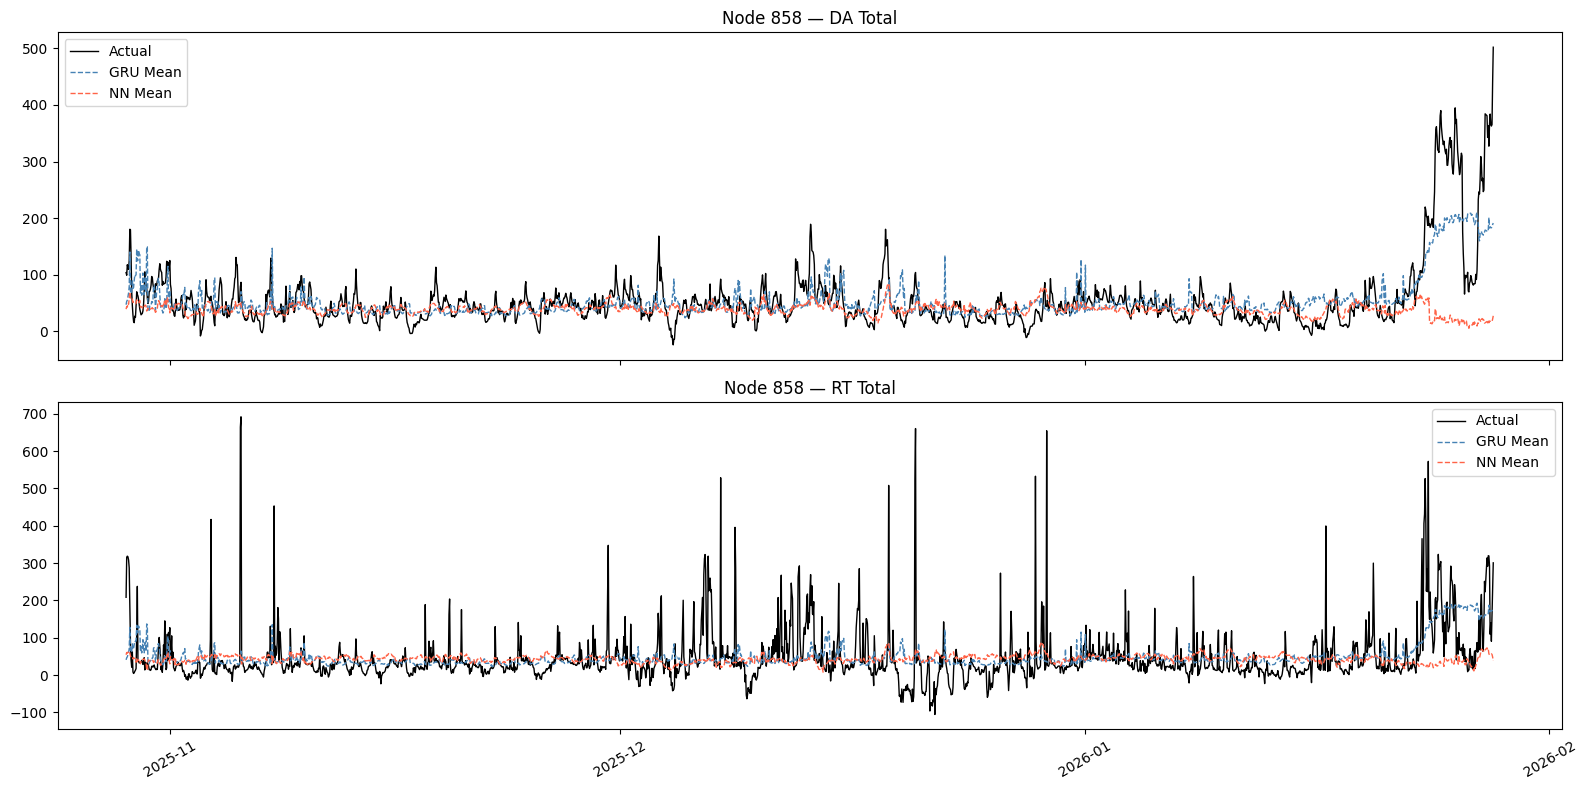

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

node_num = 858

g = gru_val[gru_val['node_num'] == node_num].sort_values('dtHr')
n = nn_val[nn_val['node_num'] == node_num].sort_values('dtHr')

x_g = pd.to_datetime(g['dtHr'])
x_n = pd.to_datetime(n['dtHr'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, col, title in zip(axes, ['da_total', 'rt_total'], ['DA Total', 'RT Total']):
    ax.plot(x_g, g[col], label='Actual', color='black', linewidth=1)
    ax.plot(x_g, g[f'{col}_mean'], label='GRU Mean', color='steelblue', linewidth=1, linestyle='--')
    ax.plot(x_n, n[f'{col}_mean'], label='NN Mean', color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'Node {node_num} — {title}')
    ax.legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()


In [20]:
gru_val[['da_total', 'rt_total']].agg(['mean', 'median', 'std'])


,da_total,rt_total
mean,36.978065,29.102066
median,24.737650,19.224600
std,60.360708,63.319044


In [ ]:
floor = 5
def mape(actual, predicted, floor=5):
    return (abs(actual - predicted) / actual.abs().clip(lower=floor)).mean()

mape_results = pd.DataFrame({
    'GRU': {
        'DA MAPE': mape(gru_val['da_total'], gru_val['da_total_mean'], floor),
        'RT MAPE': mape(gru_val['rt_total'], gru_val['rt_total_mean'], floor),
    },
    'NN': {
        'DA MAPE': mape(nn_val['da_total'], nn_val['da_total_mean'], floor),
        'RT MAPE': mape(nn_val['rt_total'], nn_val['rt_total_mean'], floor),
    }
}).round(2)


mape_results

,GRU,NN
DA MAPE,0.82,0.96
RT MAPE,1.28,1.66


In [26]:
merged = gru_val[['dt','hr','node_num','da_total','rt_total','da_total_mean','rt_total_mean']].merge(
    nn_val[['dt','hr','node_num','da_total_mean','rt_total_mean']],
    on=['dt','hr','node_num'], suffixes=('_gru','_nn')
)

merged['actual_dart']  = merged['da_total'] - merged['rt_total']
merged['gru_dart']     = merged['da_total_mean_gru'] - merged['rt_total_mean_gru']
merged['nn_dart']      = merged['da_total_mean_nn'] - merged['rt_total_mean_nn']
merged['gru_dart_err'] = abs(merged['gru_dart'] - merged['actual_dart'])
merged['nn_dart_err']  = abs(merged['nn_dart'] - merged['actual_dart'])

merged[['actual_dart','gru_dart','nn_dart','gru_dart_err','nn_dart_err']].agg(['mean','median','std']).round(2)


,actual_dart,gru_dart,nn_dart,gru_dart_err,nn_dart_err
mean,7.88,2.06,2.04,24.79,30.94
median,6.77,1.97,1.66,10.48,11.99
std,58.04,5.13,68.17,52.66,82.99


In [43]:
gru_top5 = gru_val.sort_values(['dt','hr']).groupby('node_num').head(1)
nn_top5  = nn_val.sort_values(['dt','hr']).groupby('node_num').head(1)
merged = gru_top5[['dt','hr','node_num','da_total','rt_total','da_total_mean','rt_total_mean']].merge(
    nn_top5[['dt','hr','node_num','da_total_mean','rt_total_mean']],
    on=['dt','hr','node_num'], suffixes=('_gru','_nn')
)

merged['actual_dart']  = merged['da_total'] - merged['rt_total']
merged['gru_dart']     = merged['da_total_mean_gru'] - merged['rt_total_mean_gru']
merged['nn_dart']      = merged['da_total_mean_nn'] - merged['rt_total_mean_nn']
merged['gru_dart_err'] = abs(merged['gru_dart'] - merged['actual_dart'])
merged['nn_dart_err']  = abs(merged['nn_dart'] - merged['actual_dart'])

merged[['actual_dart','gru_dart','nn_dart','gru_dart_err','nn_dart_err']].agg(['mean','median','std']).round(2)



,actual_dart,gru_dart,nn_dart,gru_dart_err,nn_dart_err
mean,4.28,1.99,1.77,16.53,17.18
median,2.99,1.86,1.20,7.19,7.96
std,38.06,6.55,17.28,34.65,37.72


## Slack + Congestion Total: Predicted Mean vs Actual

In [6]:
df_slack = pd.read_csv('/var/www/python/Qingcheng/WFiles/Ultra/GRU_val_2026-04-28.csv', index_col=0)
df_cong  = pd.read_csv('/var/www/python/Qingcheng/WFiles/Ultra/GRU_val_2026-04-29.csv', index_col=0)

merged_sc = df_slack.merge(
    df_cong[['dt','hr','node_num','da_congestion','rt_congestion','da_congestion_mean','rt_congestion_mean']],
    on=['dt','hr','node_num'], how='inner'
)

merged_sc['da_total']      = merged_sc['da_slack']      + merged_sc['da_congestion']
merged_sc['rt_total']      = merged_sc['rt_slack']       + merged_sc['rt_congestion']
merged_sc['da_total_mean'] = merged_sc['da_slack_mean']  + merged_sc['da_congestion_mean']
merged_sc['rt_total_mean'] = merged_sc['rt_slack_mean']  + merged_sc['rt_congestion_mean']

merged_sc['da_error'] = merged_sc['da_total_mean'] - merged_sc['da_total']
merged_sc['rt_error'] = merged_sc['rt_total_mean'] - merged_sc['rt_total']

print(f"Merged rows: {len(merged_sc):,}")
merged_sc[['da_total','da_total_mean','rt_total','rt_total_mean']].agg(['mean','median','std']).round(4)

Merged rows: 545,079


,da_total,da_total_mean,rt_total,rt_total_mean
mean,36.8926,30.8077,29.3238,28.7867
median,25.0509,26.7357,19.5212,25.3998
std,59.9765,28.4901,63.4723,29.5766


In [7]:
results = pd.DataFrame({
    'DA': {
        'Actual Mean':  merged_sc['da_total'].mean(),
        'Pred Mean':    merged_sc['da_total_mean'].mean(),
        'MAE':          merged_sc['da_error'].abs().mean(),
        'RMSE':         np.sqrt((merged_sc['da_error']**2).mean()),
        'Corr':         merged_sc[['da_total','da_total_mean']].corr().iloc[0,1],
        'Sign Acc':     (np.sign(merged_sc['da_total_mean']) == np.sign(merged_sc['da_total'])).mean(),
    },
    'RT': {
        'Actual Mean':  merged_sc['rt_total'].mean(),
        'Pred Mean':    merged_sc['rt_total_mean'].mean(),
        'MAE':          merged_sc['rt_error'].abs().mean(),
        'RMSE':         np.sqrt((merged_sc['rt_error']**2).mean()),
        'Corr':         merged_sc[['rt_total','rt_total_mean']].corr().iloc[0,1],
        'Sign Acc':     (np.sign(merged_sc['rt_total_mean']) == np.sign(merged_sc['rt_total'])).mean(),
    }
}).round(4)

results

,DA,RT
Actual Mean,36.8926,29.3238
Pred Mean,30.8077,28.7867
MAE,22.2641,27.1357
RMSE,47.9947,58.5576
Corr,0.6269,0.3928
Sign Acc,0.9049,0.8504
